In [27]:
from pathlib import Path
from typing import Literal

import pandas as pd
import torch
import torch.nn as nn

In [3]:
folder = Path('./output/reconstr_grid1b2')
dev = pd.read_csv(folder / 'dev.csv')
dev

,trial,config,epoch,stage,metric,value
0,0,embeddim32_hiddendims0,0,train,loss,1.121293
1,0,embeddim32_hiddendims0,0,train,mse,0.903778
2,0,embeddim32_hiddendims0,0,train,rmse,0.950673
3,0,embeddim32_hiddendims0,0,train,mae,0.667302
4,0,embeddim32_hiddendims0,0,train,r2,0.762012
...,...,...,...,...,...,...
1379995,22,embeddim256_hiddendims4,299,val,loss,0.137523
1379996,22,embeddim256_hiddendims4,299,val,mse,0.600989
1379997,22,embeddim256_hiddendims4,299,val,rmse,0.775235
1379998,22,embeddim256_hiddendims4,299,val,mae,0.507749


In [10]:
dev.columns.drop('stage')

Index(['trial', 'config', 'epoch', 'metric', 'value'], dtype='object')

In [8]:
dev.loc[dev['stage'].eq('val'), dev.columns.drop('stage')]

,trial,config,epoch,metric,value
5,0,embeddim32_hiddendims0,0,loss,1.214574
6,0,embeddim32_hiddendims0,0,mse,0.949028
7,0,embeddim32_hiddendims0,0,rmse,0.974181
8,0,embeddim32_hiddendims0,0,mae,0.687046
9,0,embeddim32_hiddendims0,0,r2,0.756690
...,...,...,...,...,...
1379995,22,embeddim256_hiddendims4,299,loss,0.137523
1379996,22,embeddim256_hiddendims4,299,mse,0.600989
1379997,22,embeddim256_hiddendims4,299,rmse,0.775235
1379998,22,embeddim256_hiddendims4,299,mae,0.507749


In [14]:
def df_dataloader(
    df: pd.DataFrame, 
    stage: str = 'val',
    agg: Literal['mean', 'last'] = 'mean',

    # default col names
    trial_col: str = 'trial',
    config_col: str = 'config',
    epoch_col: str = 'epoch',
    stage_col: str = 'stage',
    metric_col: str = 'metric',
    value_col: str = 'value'

):
    cols = df.columns.drop(stage_col)

    # filter for stage
    d = df.loc[df[stage_col].eq(stage), cols].copy()

    # handle duplicates
    if agg == 'mean':
        d = d.groupby(cols.drop(value_col).tolist(), as_index=False)[value_col].mean()
    elif agg == 'last':
        d = d.sort_values(
            [trial_col, config_col, epoch_col]
        ).groupby(
            cols.drop(value_col).tolist(),
            as_index=False
        ).last()

    # pivot
    d = d.pivot_table(
        index=[trial_col, config_col, epoch_col],
        columns=metric_col,
        values=value_col
    ).sort_index()

    # iterate
    for (trial, config, epoch), row in d.iterrows():
        yield trial, config, epoch, row.dropna().to_dict()

In [94]:
class ExpMovingAvg():
    def __init__(self, alpha: float = 0.9, warmup: int = 0):
        super().__init__()
        self.alpha = float(alpha)
        self.warmup = int(warmup)
        self.epoch = 0
        self.value = None

    def _get_alpha(self) -> float:
        if self.warmup <= 0:
            return self.alpha
        if self.epoch < self.warmup:
            return self.alpha * (self.epoch + 1) / self.warmup
        return self.alpha

    def update(self, x:float|torch.Tensor) -> float:
        # convert to float
        if torch.is_tensor(x):
            x = x.detach().item()
        x = float(x)

        # initialize ema if None
        if self.value is None:
            self.value = x

        # update ema
        else:
            alpha = self._get_alpha()
            self.value = alpha * self.value + (1 - alpha) * x

        self.epoch += 1
        return self.value

In [52]:
from collections import defaultdict

In [56]:
import matplotlib.pyplot as plt

def plot_mae_vs_ema(df, trial, config):
    sub = df[(df["trial"] == trial) & (df["config"] == config)]
    sub = sub.sort_values("epoch")

    plt.figure()
    plt.plot(sub["epoch"], sub["mae"], label="MAE")
    plt.plot(sub["epoch"], sub["ema90_mae"], label="EMA90(MAE)")
    plt.plot(sub["epoch"], sub["ema95_mae"], label="EMA95(MAE)")
    plt.plot(sub["epoch"], sub["ema99_mae"], label="EMA99(MAE)")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title(f"Trial {trial}, Config {config}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [96]:
def plot_mae_vs_ema2(df, trial, config):
    sub = df[(df["trial"] == trial) & (df["config"] == config)]
    sub = sub.sort_values("epoch")

    plt.figure()
    plt.plot(sub["epoch"], sub["mae"], label="MAE")
    plt.plot(sub["epoch"], sub["emaW0_mae"], label="EMAW0(MAE)")
    plt.plot(sub["epoch"], sub["emaW10_mae"], label="EMAW10(MAE)")
    plt.plot(sub["epoch"], sub["emaW25_mae"], label="EMAW25(MAE)")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title(f"Trial {trial}, Config {config}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [98]:
loader = df_dataloader(dev, stage='val', agg='last')
warmup = 10
ema_state90 = defaultdict(lambda: ExpMovingAvg(alpha=0.90, warmup=warmup))
ema_state95 = defaultdict(lambda: ExpMovingAvg(alpha=0.95, warmup=warmup))
ema_state99 = defaultdict(lambda: ExpMovingAvg(alpha=0.99, warmup=warmup))
ema_records = []

for trial, config, epoch, metrics in loader:
    mae = metrics['mae']
    ema90 = ema_state90[(trial, config)]
    ema90_mae = ema90.update(mae)

    ema95 = ema_state95[(trial, config)]
    ema95_mae = ema95.update(mae)

    ema99 = ema_state99[(trial, config)]
    ema99_mae = ema99.update(mae)

    ema_records.append({
        'trial': trial,
        'config': config,
        'epoch': epoch,
        'mae': mae,
        'ema90_mae': ema90_mae,
        'ema95_mae': ema95_mae,
        'ema99_mae': ema99_mae,
    })

df_ema = pd.DataFrame(ema_records)

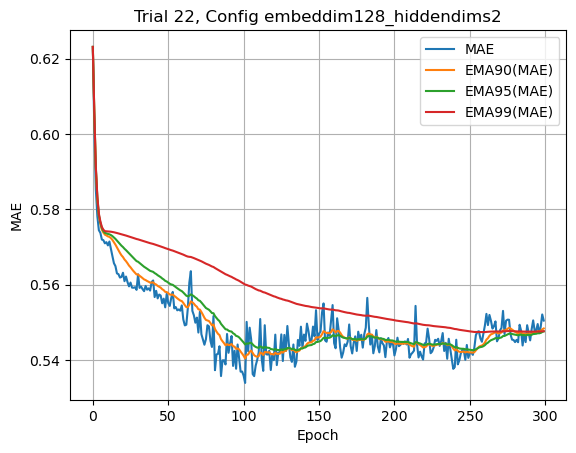

In [110]:
plot_mae_vs_ema(df_ema, trial=22, config="embeddim128_hiddendims2")

In [95]:
loader = df_dataloader(dev, stage='val', agg='last')
alpha = 0.90
ema_stateW0 = defaultdict(lambda: ExpMovingAvg(alpha=alpha, warmup=5))
ema_stateW10 = defaultdict(lambda: ExpMovingAvg(alpha=alpha, warmup=10))
ema_stateW25 = defaultdict(lambda: ExpMovingAvg(alpha=alpha, warmup=25))
ema_records = []

for trial, config, epoch, metrics in loader:
    mae = metrics['mae']
    emaW0 = ema_stateW0[(trial, config)]
    emaW0_mae = emaW0.update(mae)

    emaW10 = ema_stateW10[(trial, config)]
    emaW10_mae = emaW10.update(mae)

    emaW25 = ema_stateW25[(trial, config)]
    emaW25_mae = emaW25.update(mae)

    ema_records.append({
        'trial': trial,
        'config': config,
        'epoch': epoch,
        'mae': mae,
        'emaW0_mae': emaW0_mae,
        'emaW10_mae': emaW10_mae,
        'emaW25_mae': emaW25_mae,
    })

df_ema = pd.DataFrame(ema_records)

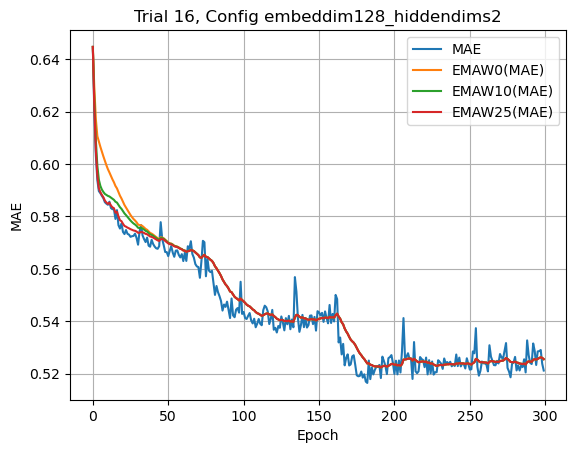

In [97]:
plot_mae_vs_ema2(df_ema, trial=16, config="embeddim128_hiddendims2")
